<a href="https://colab.research.google.com/github/Fergit42/Fergit42/blob/main/VECM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

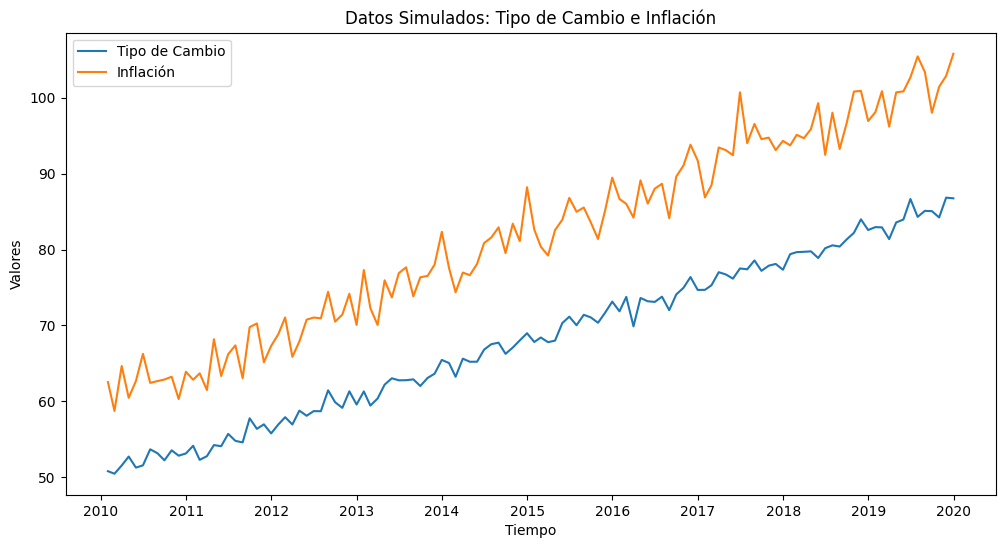

Prueba de Cointegración Engle-Granger: Estadístico = -11.84, p-valor = 0.0000
Orden óptimo para VECM: {'aic': 4, 'bic': 1, 'hqic': 4, 'fpe': 4}
Rango de Cointegración Seleccionado: 1
Coeficientes de Cointegración:
[[0.07621267]
 [0.09123141]]


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_date

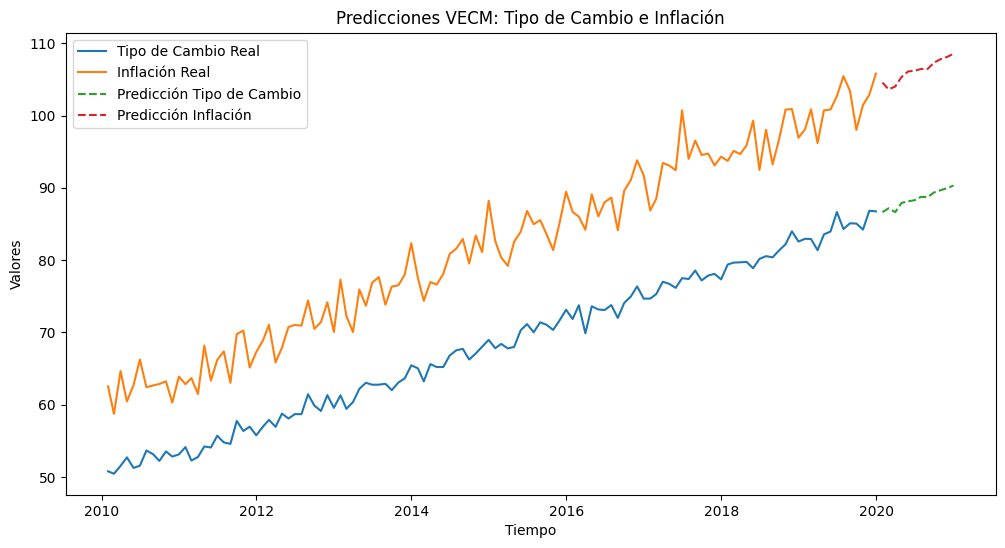

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import VECM, select_order, select_coint_rank
from statsmodels.tsa.stattools import coint

# Simulación de datos (tipo de cambio e inflación con relación de cointegración)
np.random.seed(42)
n = 120
t = np.arange(1, n + 1)
tipo_cambio = 50 + 0.3 * t + np.random.normal(scale=1, size=n)
inflacion = 1.2 * tipo_cambio + np.random.normal(scale=2, size=n)

# Crear DataFrame con los datos simulados
data = pd.DataFrame({'Tipo_Cambio': tipo_cambio, 'Inflacion': inflacion})
data['Mes'] = pd.date_range(start='2010-01', periods=n, freq='ME')
data.set_index('Mes', inplace=True)

# Visualización de los datos
plt.figure(figsize=(12, 6))
plt.plot(data['Tipo_Cambio'], label='Tipo de Cambio')
plt.plot(data['Inflacion'], label='Inflación')
plt.title('Datos Simulados: Tipo de Cambio e Inflación')
plt.xlabel('Tiempo')
plt.ylabel('Valores')
plt.legend()
plt.show()

# Prueba de cointegración Engle-Granger
coint_test = coint(data['Tipo_Cambio'], data['Inflacion'])
print(f"Prueba de Cointegración Engle-Granger: Estadístico = {coint_test[0]:.2f}, p-valor = {coint_test[1]:.4f}")

# Selección de orden para VECM
order = select_order(data[['Tipo_Cambio', 'Inflacion']], maxlags=10, deterministic="ci")
print(f"Orden óptimo para VECM: {order.selected_orders}")

# Selección de rango de cointegración
coint_rank = select_coint_rank(data[['Tipo_Cambio', 'Inflacion']], det_order=0, k_ar_diff=order.selected_orders['aic'], signif=0.05)
print(f"Rango de Cointegración Seleccionado: {coint_rank.rank}")

# Ajuste del modelo VECM
vecm_model = VECM(data[['Tipo_Cambio', 'Inflacion']], k_ar_diff=order.selected_orders['aic'], coint_rank=coint_rank.rank, deterministic="ci")
vecm_fit = vecm_model.fit()

# Visualización de los coeficientes de cointegración
print("Coeficientes de Cointegración:")
print(vecm_fit.alpha)

# Predicciones a corto plazo con VECM
forecast = vecm_fit.predict(steps=12)
forecast_index = pd.date_range(start=data.index[-1], periods=13, freq='ME')[1:]
forecast_df = pd.DataFrame(forecast, columns=['Tipo_Cambio', 'Inflacion'], index=forecast_index)

# Visualización de predicciones
plt.figure(figsize=(12, 6))
plt.plot(data['Tipo_Cambio'], label='Tipo de Cambio Real')
plt.plot(data['Inflacion'], label='Inflación Real')
plt.plot(forecast_df['Tipo_Cambio'], label='Predicción Tipo de Cambio', linestyle='--')
plt.plot(forecast_df['Inflacion'], label='Predicción Inflación', linestyle='--')
plt.title('Predicciones VECM: Tipo de Cambio e Inflación')
plt.xlabel('Tiempo')
plt.ylabel('Valores')
plt.legend()
plt.show()
